## Score - 83620 
- #### updated after understanding correlation heatmap of feature engineered data, 5 values for location are highly correlated.

In [233]:
import numpy as np 
import pandas as pd  
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

In [234]:
pd.read_csv('/kaggle/input/datasets/vedikagupta0/climate-risk-health-prediction-challenge/SampleSubmission.csv').sample(5)

,ID,TargetF1,TargetRAUC
926,ID_4DF5742A,0,0
405,ID_987CE5E3,0,0
46,ID_4738ABDA,0,0
42,ID_5FCD1EA3,0,0
496,ID_6D6AD6DD,0,0


In [235]:
data_dict =pd.read_csv('/kaggle/input/datasets/vedikagupta0/climate-risk-health-prediction-challenge/data_dictionary.csv')

In [236]:
df = pd.read_csv('/kaggle/input/datasets/vedikagupta0/climate-risk-health-prediction-challenge/Train.csv')

In [237]:
df["is_climate_sensitive"].value_counts()

is_climate_sensitive
1    2047
0    1099
Name: count, dtype: int64

In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3146 entries, 0 to 3145
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    3146 non-null   object 
 1   zone                  3146 non-null   object 
 2   gender                3146 non-null   object 
 3   deathdate             3146 non-null   object 
 4   age                   3146 non-null   float64
 5   avg_temperature       3146 non-null   float64
 6   max_temperature       3146 non-null   float64
 7   min_temperature       3146 non-null   float64
 8   precipitation         3146 non-null   float64
 9   latitude              3146 non-null   float64
 10  longitude             3146 non-null   float64
 11  location              3146 non-null   object 
 12  is_climate_sensitive  3146 non-null   int64  
dtypes: float64(7), int64(1), object(5)
memory usage: 319.6+ KB


In [239]:
prec_quant_75 = df["precipitation"].quantile(.75)
prec_quant_90 = df["precipitation"].quantile(.90)

In [240]:
def preprocessor(data, fit=True, le=None, target=None, location_te=None, maxloc=1,prec_quant_75=prec_quant_75, prec_quant_90= prec_quant_90):
    data = data.copy()

    data['zone'] = (data['zone'] == 'Peri_urban').astype(int)
    data['gender'] = (data['gender'] == 'Male').astype(int)

    data['age'] = data['age'].astype(int)
    data['age_group'] = pd.cut(
        data['age'],
        bins=[-1, 10, 20, 30, 40, 50, 60, 70, 80, 90, np.inf],
        labels=False
    ) + 1

    data['is_young'] = data['age']<=20
    data["is_rain"] = (data["precipitation"] > 0).astype(int)

    data["is_heavy_rain"] = (
        data["precipitation"] > prec_quant_75
    ).astype(int)

    data["is_extreme_rain"] = (
        data["precipitation"] > prec_quant_90
    ).astype(int)

    data["precip_log"] = np.log1p(data["precipitation"])

    data["precip_per_temp"] = (
        data["precipitation"] /
        (abs(data["avg_temperature"]) + 1)
    )

    data["temp_rain_interaction"] = (
        data["avg_temperature"] *
        data["precipitation"]
    )


    data["temp_range"] = (
        data["max_temperature"] -
        data["min_temperature"]
    )

    data["avg_temp_position"] = (
        (data["avg_temperature"] - data["min_temperature"]) /
        (data["max_temperature"] - data["min_temperature"] + 1e-6)
    )

    loc_cols = [f"location_{i+1}" for i in range(maxloc)]

    location_split = data["location"].str.split(",", expand=True)

    for i, col in enumerate(loc_cols):
        if i < location_split.shape[1]:
            data[col] = location_split[i].str.strip()
        else:
            data[col] = "Unknown"

    data['deathdate'] = pd.to_datetime(
        data['deathdate'],
        errors='coerce'
    )

    data['date'] = data['deathdate'].dt.day
    data['month'] = data['deathdate'].dt.month
    data['year'] = data['deathdate'].dt.year
    data['day_of_week'] = data['deathdate'].dt.dayofweek
    data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)
    data['quarter'] = data['deathdate'].dt.quarter
    data['day_of_year'] = data['deathdate'].dt.dayofyear
    data['week_of_year'] = (
        data['deathdate'].dt.isocalendar().week.astype(int)
    )

    if fit:
        if target is None:
            raise ValueError("target must be provided when fit=True")

        global_mean = data[target].mean()
        location_te = {}

        for col in loc_cols:
            stats = pd.DataFrame({
                'location': data[col],
                'target': data[target]
            }).groupby('location')['target'].agg(
                ['mean', 'count']
            )

            smoothing = 10

            stats['encoded'] = (
                (stats['count'] * stats['mean']) +
                (smoothing * global_mean)
            ) / (
                stats['count'] + smoothing
            )

            location_te[col] = {
                'mapping': stats['encoded'].to_dict(),
                'global_mean': global_mean
            }

            data[col] = data[col].map(
                location_te[col]['mapping']
            ).fillna(global_mean)

        data.drop(
            columns=['deathdate', 'location'],
            inplace=True
        )

        return data, location_te

    else:
        for col in loc_cols:
            mapping = location_te[col]['mapping']
            global_mean = location_te[col]['global_mean']

            data[col] = (
                data[col]
                .map(mapping)
                .fillna(global_mean)
            )

        data.drop(
            columns=['deathdate', 'location'],
            inplace=True
        )

        return data

In [241]:
df1, le_training = preprocessor(df, fit=True, target='is_climate_sensitive')

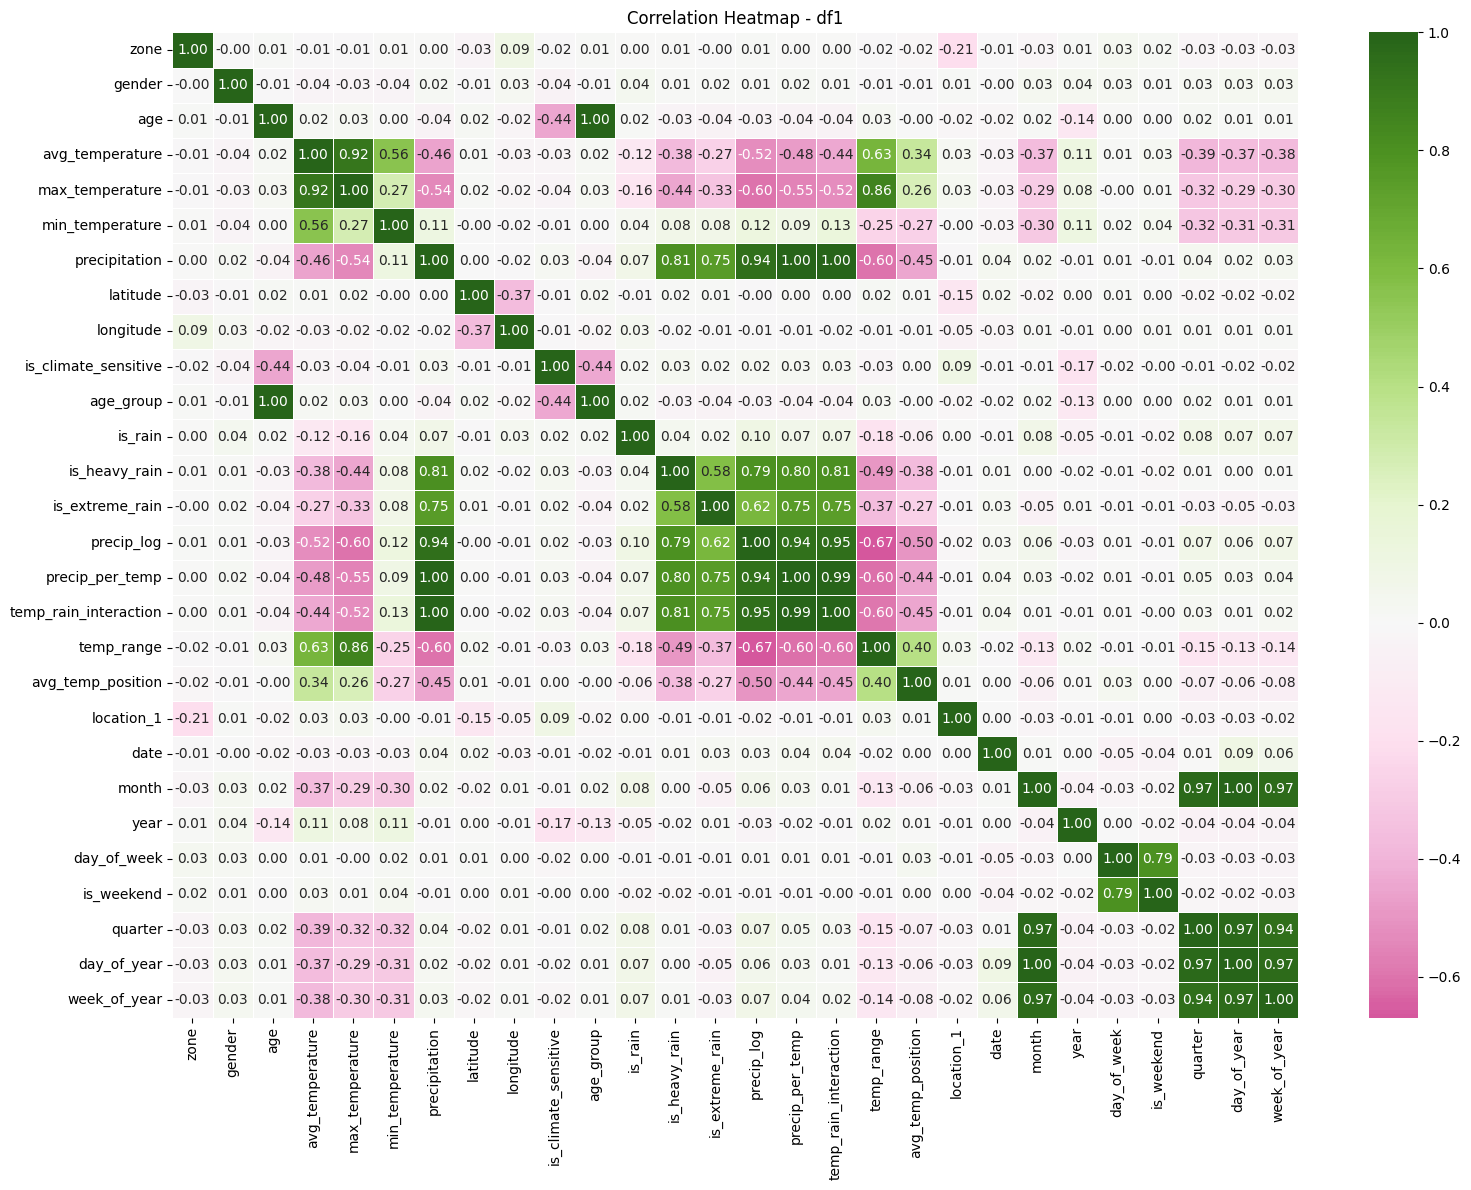

In [242]:
plt.figure(figsize=(16, 12))

corr = df1.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="PiYG",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap - df1")
plt.tight_layout()
plt.show()

In [243]:
X = df1.drop(columns=["is_climate_sensitive", "ID"])
y = df1["is_climate_sensitive"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [244]:
models = {

    "Gradient Boosting": GradientBoostingClassifier(
        learning_rate=0.01,
        min_samples_leaf=5,
        min_samples_split=10,
        n_estimators=300,
        random_state=42,
        subsample=0.9
    ),

    "Extra Trees": ExtraTreesClassifier(
        max_depth=5,
        max_features=None,
        min_samples_leaf=2,
        min_samples_split=5,
        n_estimators=500,
        n_jobs=-1,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        max_depth=5,
        max_features=None,
        min_samples_split=10,
        n_estimators=700,
        n_jobs=-1,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        colsample_bytree=1.0,
        eval_metric="logloss",
        gamma=0.1,
        learning_rate=0.01,
        max_depth=4,
        min_child_weight=3,
        n_estimators=300,
        n_jobs=-1,
        random_state=42
    )
}

tuned_models = {}
results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    tuned_models[name] = model

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    final_score = 0.6 * f1 + 0.4 * roc_auc

    results.append({
        "Model": name,
        "Parameters": model.get_params(),
        "F1": f1,
        "ROC-AUC": roc_auc,
        "Final Score": final_score,
        "Threshold": 0.5
    })

results_df = pd.DataFrame(results).sort_values(
    "Final Score",
    ascending=False
).reset_index(drop=True)

print(results_df)

               Model                                         Parameters  \
0  Gradient Boosting  {'ccp_alpha': 0.0, 'criterion': 'friedman_mse'...   
1      Random Forest  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...   
2            XGBoost  {'objective': 'binary:logistic', 'base_score':...   
3        Extra Trees  {'bootstrap': False, 'ccp_alpha': 0.0, 'class_...   

         F1   ROC-AUC  Final Score  Threshold  
0  0.826636  0.841718     0.832669        0.5  
1  0.817229  0.836519     0.824945        0.5  
2  0.816279  0.835299     0.823887        0.5  
3  0.816471  0.834457     0.823665        0.5  


In [245]:
tf = pd.read_csv('/kaggle/input/datasets/vedikagupta0/climate-risk-health-prediction-challenge/Test.csv')

In [246]:
tf1 = preprocessor(tf, fit=False, location_te=le_training, maxloc=1)

In [247]:
tf1.head()

,ID,zone,gender,age,avg_temperature,max_temperature,min_temperature,precipitation,latitude,longitude,...,avg_temp_position,location_1,date,month,year,day_of_week,is_weekend,quarter,day_of_year,week_of_year
0,ID_E760D84B,0,0,75,21.224387,24.632729,18.145633,4.295335,0.616667,33.500000,...,0.474597,0.650668,24,11,2007,5,1,4,328,47
1,ID_6EDEA907,0,0,50,21.708596,25.184528,18.285274,1.376196,0.725422,33.098845,...,0.496187,0.650668,23,1,2008,2,0,1,23,4
2,ID_B9FFC8D8,0,0,76,21.371149,24.584523,18.866490,2.336643,0.603194,33.542370,...,0.438028,0.650668,14,3,2008,4,0,1,74,11
3,ID_74C6C94E,1,0,90,21.341990,25.188662,17.998317,4.703071,-0.590211,30.056939,...,0.465022,0.650668,16,4,2008,2,0,2,107,16
4,ID_0E02825D,0,1,8,19.710391,22.905167,18.082628,4.066863,0.603194,33.542370,...,0.337532,0.650668,21,4,2008,0,0,2,112,17


In [248]:
df1.describe()

,zone,gender,age,avg_temperature,max_temperature,min_temperature,precipitation,latitude,longitude,is_climate_sensitive,...,avg_temp_position,location_1,date,month,year,day_of_week,is_weekend,quarter,day_of_year,week_of_year
count,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,...,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000,3146.000000
mean,0.373172,0.522886,24.243484,22.066541,26.206879,18.514193,1.519907,0.630242,33.407442,0.650668,...,0.458298,0.650268,15.243802,6.504768,2013.834075,3.013032,0.290210,2.494914,182.079148,26.541322
std,0.483724,0.499555,31.428833,1.095122,1.691347,0.891524,1.621088,0.172728,0.579933,0.476835,...,0.039822,0.034749,8.668309,3.427209,4.195894,2.009395,0.453931,1.100429,104.823557,14.988211
min,0.000000,0.000000,0.000000,18.852803,20.884623,15.018778,0.000000,0.089819,30.782817,0.000000,...,0.328813,0.577437,1.000000,1.000000,2007.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,21.319885,25.260527,17.954814,0.286814,0.564758,33.473515,0.000000,...,0.431917,0.632025,8.000000,4.000000,2010.000000,1.000000,0.000000,2.000000,95.000000,14.000000
50%,0.000000,1.000000,3.000000,21.931299,26.081829,18.510478,1.034344,0.591961,33.483544,1.000000,...,0.459298,0.639921,15.000000,6.000000,2013.000000,3.000000,0.000000,2.000000,177.000000,26.000000
75%,1.000000,1.000000,49.000000,22.652860,27.015877,19.040655,2.222345,0.608396,33.519695,1.000000,...,0.486534,0.672296,23.000000,9.000000,2017.000000,5.000000,1.000000,3.000000,271.000000,39.000000
max,1.000000,1.000000,110.000000,27.012223,34.080947,21.849602,16.606523,1.187892,34.226647,1.000000,...,0.623699,0.786032,31.000000,12.000000,2022.000000,6.000000,1.000000,4.000000,366.000000,53.000000


In [249]:
def make_submission(
    test_data,
    model,
    id_col="ID"
):
    ids = test_data.pop(id_col)

    pred_binary = model.predict(test_data)
    pred_prob = model.predict_proba(test_data)[:, 1]
    submission = pd.DataFrame({
        "ID": ids,
        "TargetF1": pred_binary.astype(int),
        "TargetRAUC": pred_prob
    })

    return submission

In [251]:
best_name = results_df.iloc[0]["Model"]
best_model = tuned_models[best_name]

X_full = df1.drop(columns=["is_climate_sensitive", "ID"])
y_full = df1["is_climate_sensitive"]

best_model.fit(X_full, y_full)

X_submission = tf1.drop(columns=["ID"])
ids = tf1["ID"].copy()

pred_prob = best_model.predict_proba(X_submission)[:, 1]
pred_binary = (pred_prob >= 0.5).astype(int)

submission = pd.DataFrame({
    "ID": ids,
    "TargetF1": pred_binary,
    "TargetRAUC": pred_prob
})

submission.to_csv("climate-risk-fe-hpt-3.csv", index=False)

print("Best model:", best_name)
print(submission.head())

Best model: Gradient Boosting
            ID  TargetF1  TargetRAUC
0  ID_E760D84B         1    0.526274
1  ID_6EDEA907         1    0.675773
2  ID_B9FFC8D8         1    0.521443
3  ID_74C6C94E         0    0.427991
4  ID_0E02825D         1    0.699793
